# ***Unsupervised Models: K-Means & Hierarchical Clustering***

In [1]:
# Library
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV , GridSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score ,confusion_matrix, roc_curve, auc , silhouette_score
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage , fcluster
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_blobs

# ***Data Preprocessing***

In [2]:
# Download the Adult_Income dataset from Kaggle
dataset_path = kagglehub.dataset_download('serpilturanyksel/adult-income')

# construct the full path to the adult11.csv file.
file_path = os.path.join(dataset_path, 'adult11.csv')

# Load the dataset using pandas
adult = pd.read_csv(file_path)
adult.head()

100%|██████████| 652k/652k [00:00<00:00, 819kB/s]

Extracting files...


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# null values
adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [4]:
# count ? sign
( adult == "?").sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [5]:
# andle ? sign
adult = adult.replace('?', np.nan)
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
# Impute categorical columns with 'most_frequent' strategy
simple_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# Apply imputation to relevant columns
adult['workclass'] = simple_cat.fit_transform(adult[['workclass']]).ravel()
adult['occupation'] = simple_cat.fit_transform(adult[['occupation']]).ravel()
adult['native-country'] = simple_cat.fit_transform(adult[['native-country']]).ravel()
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [7]:
# label encoding for (income); convert  <=50K to 1 & >50K to 0
lable_income = LabelEncoder()
adult['salary'] = lable_income.fit_transform(adult['salary'])
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,0


In [8]:
# # Encode categorical columns using label encoding
categorical_col = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country']
label_encoder = LabelEncoder()
for col in categorical_col:
    adult[col] = label_encoder.fit_transform(adult[col])

# Display
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38,1
4,18,3,103497,15,10,4,9,3,4,0,0,0,30,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,0
48838,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,1
48839,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,0
48840,22,3,201490,11,9,4,0,3,4,1,0,0,20,38,0


In [9]:
# Drop label
x_adult_unsupervised = adult.drop('salary', axis=1)
y_adult = adult['salary']   # Save labels in a list for validation

In [10]:
# Scale/standardize
scaler_adult2 = StandardScaler()
X_adult2_scaled = scaler_adult2.fit_transform(x_adult_unsupervised)
X_adult2_scaled

array([[-0.99512893, -0.08972675,  0.35167453, ..., -0.2171271 ,
        -0.03408696,  0.25969378],
       [-0.04694151, -0.08972675, -0.94552415, ..., -0.2171271 ,
         0.77292975,  0.25969378],
       [-0.77631645, -1.8902337 ,  1.3947231 , ..., -0.2171271 ,
        -0.03408696,  0.25969378],
       ...,
       [ 1.41180837, -0.08972675, -0.35751025, ..., -0.2171271 ,
        -0.03408696,  0.25969378],
       [-1.21394141, -0.08972675,  0.11198424, ..., -0.2171271 ,
        -1.64812038,  0.25969378],
       [ 0.97418341,  0.81052673,  0.93049361, ..., -0.2171271 ,
        -0.03408696,  0.25969378]])

# ***Models Building & Evaluation then Visualization***

> # K-Means

In [11]:
# K-means
kmeans_adult2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_adult2.fit(X_adult2_scaled)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [12]:
# Evaluate (make predict)
clusters_kmeans_pred_adult2 = kmeans_adult2.predict(X_adult2_scaled)

In [13]:
# Compute a Silhouette Score
kmeans_silhouette_adult2 = silhouette_score(X_adult2_scaled, clusters_kmeans_pred_adult2)
print(f"K-Means Silhouette Score: {kmeans_silhouette_adult2:.4f}")

K-Means Silhouette Score: 0.1348


In [14]:
# Compare clusters to true labels with a simple table
table_adult2 = pd.crosstab(y_adult, clusters_kmeans_pred_adult2, rownames=['True Labels'], colnames=['K-Means Clusters'])
print("\nK-Means Cluster vs. True Labels:")
print(table_adult2)


K-Means Cluster vs. True Labels:
K-Means Clusters      0      1
True Labels                   
0                 18069  19086
1                 10019   1668


> # Hierarchical Clustering

In [15]:
# Sampling the data for Hierarchical Clustering
sample_size = 1000
np.random.seed(42)
sample_indices = np.random.choice(X_adult2_scaled.shape[0], size=sample_size, replace=False)
X_sample_adult = X_adult2_scaled[sample_indices]
y_sample_adult = y_adult.iloc[sample_indices]

In [16]:
# Linkage methods: single, complete, average
linkage_methods = ['single', 'complete', 'average']
hierarchical_results_adult = {}

In [17]:
for method in linkage_methods:  # Apply AgglomerativeClustering on sampled data
    hierarchical_adult2 = AgglomerativeClustering(n_clusters=2, linkage=method)
    clusters_hierarchical_pred_adult2 = hierarchical_adult2.fit_predict(X_sample_adult)

    # Evaluate on sampled data
    silhouette_avg = silhouette_score(X_sample_adult, clusters_hierarchical_pred_adult2)
    hierarchical_results_adult[method] = silhouette_avg

    # Store the best result for later visualization
    if method == 'complete': # complete linkage for the main visualization
        best_agg_labels_adult = clusters_hierarchical_pred_adult2
        best_hierarchical_method_adult = method

print("\nAll Hierarchical Clustering Silhouette Scores:")
for method, score in hierarchical_results_adult.items():
    print(f"  {method}: {score:.4f}")


All Hierarchical Clustering Silhouette Scores:
  single: 0.6558
  complete: 0.6558
  average: 0.6558


In [18]:
# Compare clusters to true labels with a simple table
table_adult2 = pd.crosstab(y_sample_adult, clusters_hierarchical_pred_adult2, rownames=['True Labels'], colnames=['Hierarchical Clusters'])
print("\nK-hierarchical Cluster vs. True Labels:")
print(table_adult2)


K-hierarchical Cluster vs. True Labels:
Hierarchical Clusters    0  1
True Labels                  
0                      769  0
1                      227  4


Text(0, 0.5, 'PCA Component 2')

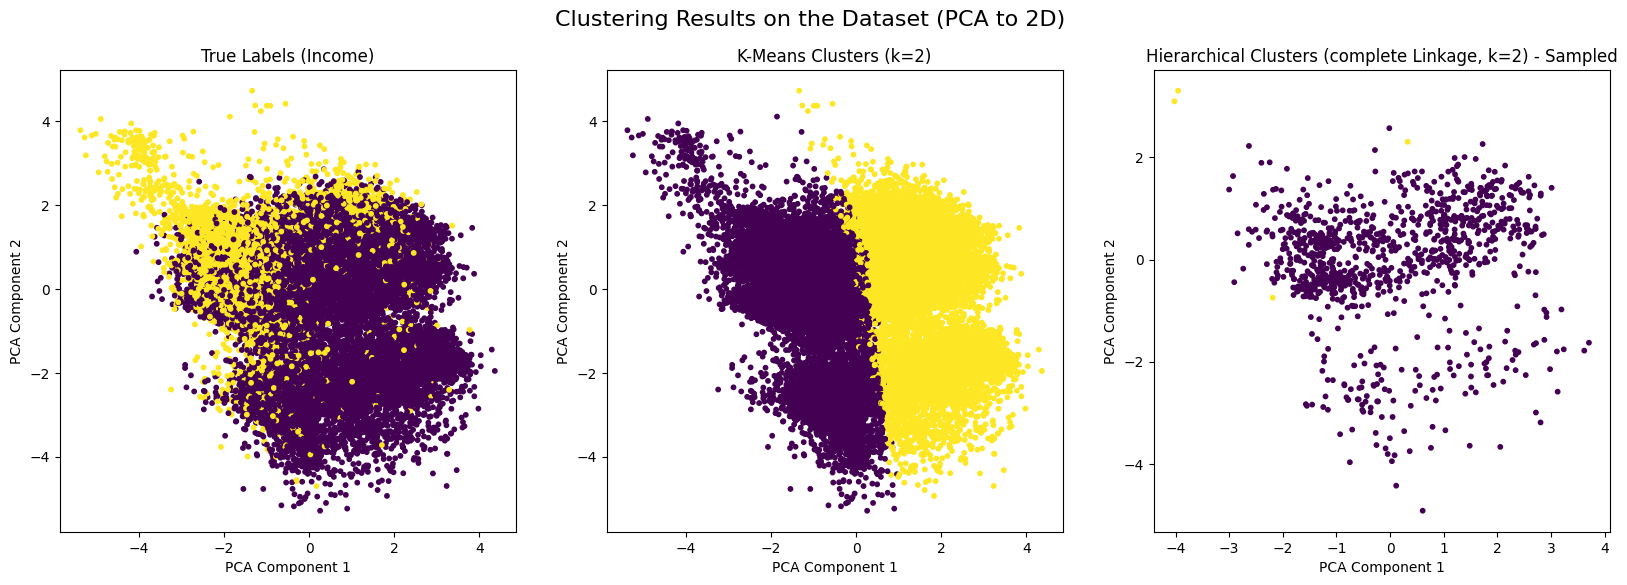

In [19]:
# ((Reduce dimensionality to 2D using PCA))
pca_adult = PCA(n_components=2)
X_pca_adult = pca_adult.fit_transform(X_adult2_scaled)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Clustering Results on the Dataset (PCA to 2D)', fontsize=16)

# Plot 1: True Labels
scatter1 = axes[0].scatter(X_pca_adult[:, 0], X_pca_adult[:, 1], c=y_adult, cmap='viridis', s=10)
axes[0].set_title('True Labels (Income)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Plot 2: K-Means
scatter2 = axes[1].scatter(X_pca_adult[:, 0], X_pca_adult[:, 1], c=clusters_kmeans_pred_adult2, cmap='viridis', s=10)
axes[1].set_title('K-Means Clusters (k=2)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

# Plot 3: Hierarchical (Sampled Data)
X_pca_sample_adult = X_pca_adult[sample_indices, :]
scatter3 = axes[2].scatter(X_pca_sample_adult[:, 0], X_pca_sample_adult[:, 1], c=best_agg_labels_adult, cmap='viridis', s=10)
axes[2].set_title(f'Hierarchical Clusters ({best_hierarchical_method_adult} Linkage, k=2) - Sampled')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')

Text(0, 0.5, 'Distance')

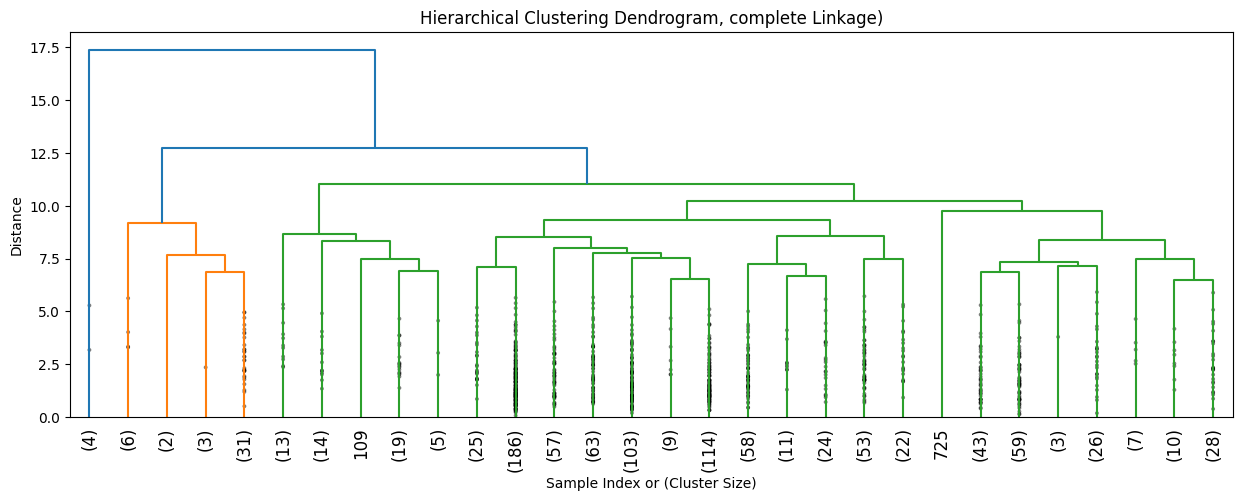

In [20]:
# Dendrogram for Hierarchical Clustering (Sampled Data)
linked_adult = linkage(X_sample_adult, method=best_hierarchical_method_adult) # Perform linkage on the sampled data [using the best method]

# Plot the dendrogram
plt.figure(figsize=(15,5))
dendrogram(
    linked_adult,
    orientation='top',
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
)
plt.title(f'Hierarchical Clustering Dendrogram, {best_hierarchical_method_adult} Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')

# **Model Performance Comparison**

In [21]:
print("\n Model Performance Comparison: ")
print(f"K-Means Silhouette Score: {kmeans_silhouette_adult2:.4f}")

print(f"Hierarchical Clustering ({best_hierarchical_method_adult}): {hierarchical_results_adult[best_hierarchical_method_adult]:.4f}")
print("\nK-Means Cluster vs. True Labels:\n")
print(table_adult2)

print("\nHierarchical Cluster vs. True Labels:\n")
print(table_adult2)


 Model Performance Comparison: 
K-Means Silhouette Score: 0.1348
Hierarchical Clustering (complete): 0.6558

K-Means Cluster vs. True Labels:

Hierarchical Clusters    0  1
True Labels                  
0                      769  0
1                      227  4

Hierarchical Cluster vs. True Labels:

Hierarchical Clusters    0  1
True Labels                  
0                      769  0
1                      227  4


/tmp/ipykernel_7906/2284958453.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=silhouette_scores, palette='viridis')


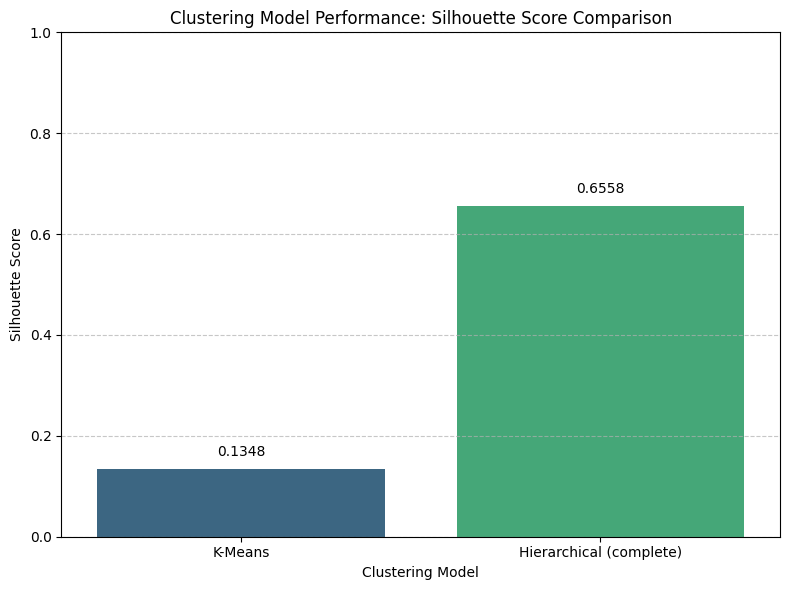

In [22]:
models = ['K-Means', f'Hierarchical ({best_hierarchical_method_adult})']
silhouette_scores = [kmeans_silhouette_adult2, hierarchical_results_adult[best_hierarchical_method_adult]]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=silhouette_scores, palette='viridis')
plt.title('Clustering Model Performance: Silhouette Score Comparison')
plt.xlabel('Clustering Model')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1) # Silhouette scores are between -1 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, score in enumerate(silhouette_scores):
    plt.text(index, score + 0.02, f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()